In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")
import numpy as np
import pandas as pd
import gudhi as gd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
import os
from utils.silhouette import compute_silhouette
from estimators import ipw_estimator, plugin_estimator, aipw_estimator
from utils.generate import gen_covariate, gen_trt_prob
from utils.utils import numerical_integration, fit_functional_regression
from scipy.stats import gaussian_kde

/Users/hajinlee/miniconda3/envs/topo_causal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Download & load data

In [ ]:
# download latest version
os.environ['KAGGLEHUB_CACHE'] = './'
path = kagglehub.dataset_download("plameneduardo/sarscov2-ctscan-dataset")

print("Path to dataset files:", path)

In [4]:
# load data
root_dir = "./datasets/plameneduardo/sarscov2-ctscan-dataset/versions/2"

# infected
infected = []
for file in os.listdir(f"{root_dir}/COVID"):
    img = Image.open(f"{root_dir}/COVID/{file}")
    arr = np.array(img) / 255       # normalize pixels between 0~1
    infected.append(arr[:,:,0])     # discard redundant channels and only use the first one

# non-infected
noninfected = []
for file in os.listdir(f"{root_dir}/non-COVID"):
    img = Image.open(f"{root_dir}/non-COVID/{file}")
    arr = np.array(img) / 255
    noninfected.append(arr[:,:,0])

# Transform to silhouette

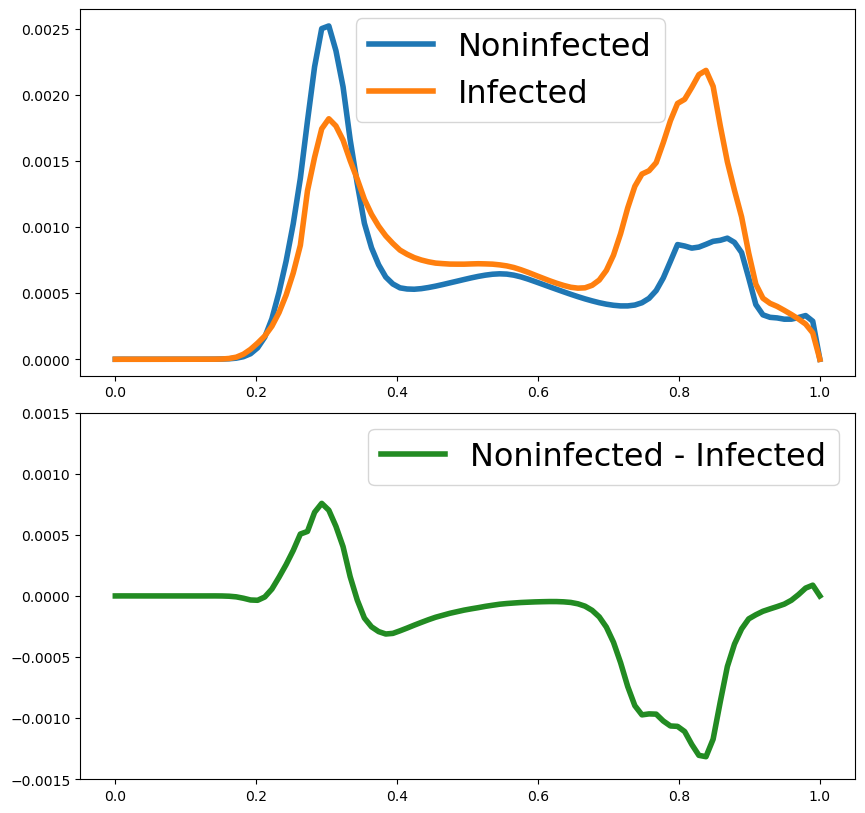

In [5]:
np.random.seed(42)
interval = [0, 1]
r = .1
resolution = 100
tseq=np.linspace(*interval, resolution)

# infected
phi_infected = []
for data in infected:
    cub_cpx = gd.CubicalComplex(vertices=data)
    cub_cpx.compute_persistence()

    diag0 = cub_cpx.persistence_intervals_in_dimension(0)
    diag0 = diag0[~np.isinf(diag0).any(axis=1)]     # remove infinite filtration value from 1-dim diagram
    # diag1 = cub_cpx.persistence_intervals_in_dimension(1)

    silhouette = compute_silhouette([diag0], interval=interval, r=r, resolution=resolution)  # shape [2, res]
    # silhouette = compute_silhouette([diag0, diag1], interval=[0,1], r=r, res=res)   # shape [2, res]
    phi_infected.append(silhouette)

# non-infected
phi_noninfected = []
for data in noninfected:
    cub_cpx = gd.CubicalComplex(vertices=data)
    cub_cpx.compute_persistence()

    diag0 = cub_cpx.persistence_intervals_in_dimension(0)
    diag0 = diag0[~np.isinf(diag0).any(axis=1)]
    # diag1 = cub_cpx.persistence_intervals_in_dimension(1)

    silhouette = compute_silhouette([diag0], interval=interval, r=r, resolution=resolution)
    # silhouette = compute_silhouette([diag0, diag1], interval=[0,1], r=r, res=res)
    phi_noninfected.append(silhouette)


phi_infected = np.stack(phi_infected)
phi_noninfected = np.stack(phi_noninfected)

# shuffle data
np.random.shuffle(phi_infected)
np.random.shuffle(phi_noninfected)

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

axs[0].plot(tseq, phi_noninfected[:, 0, :].mean(0), label="Noninfected", lw=4)
axs[0].plot(tseq, phi_infected[:, 0, :].mean(0), label="Infected", lw=4)
# axs[0].set_title("Average Silhouette in H0", fontsize=15)
axs[0].legend(fontsize=23, bbox_to_anchor=(0.555, .65))

axs[1].plot(tseq, phi_noninfected[:, 0, :].mean(0) - phi_infected[:, 0, :].mean(0), label="Noninfected - Infected", lw=4, color='forestgreen')
# axs[1].set_title("Difference of Average Silhouette in H0", fontsize=15)
axs[1].set_ylim(-0.0015, 0.0015)
axs[1].legend(fontsize=23)
plt.subplots_adjust(hspace=0.1)
plt.show();

## Illustration

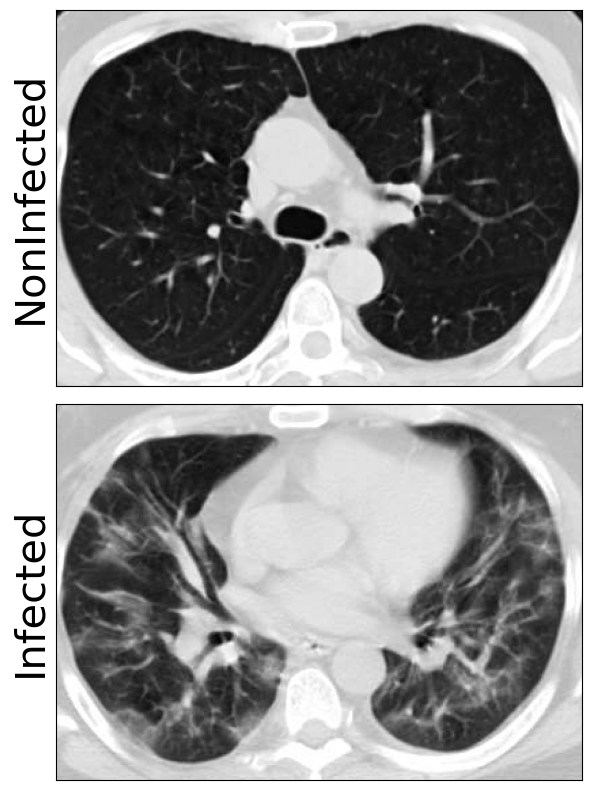

/Users/hajinlee/miniconda3/envs/topo_causal/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:134: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


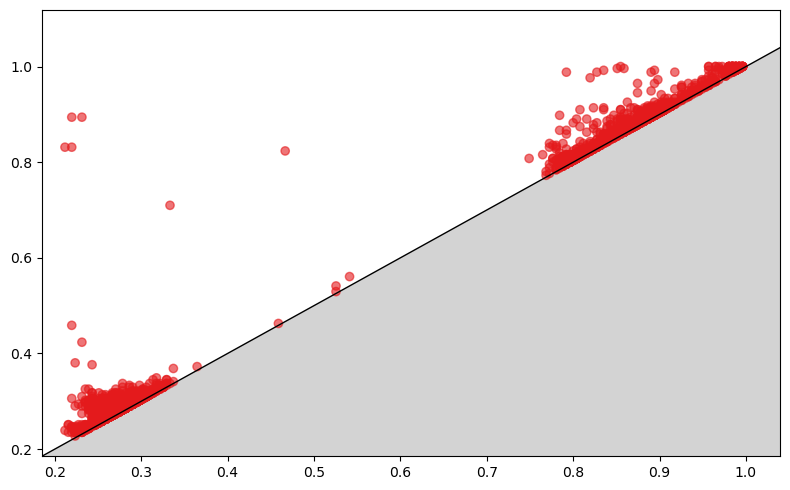

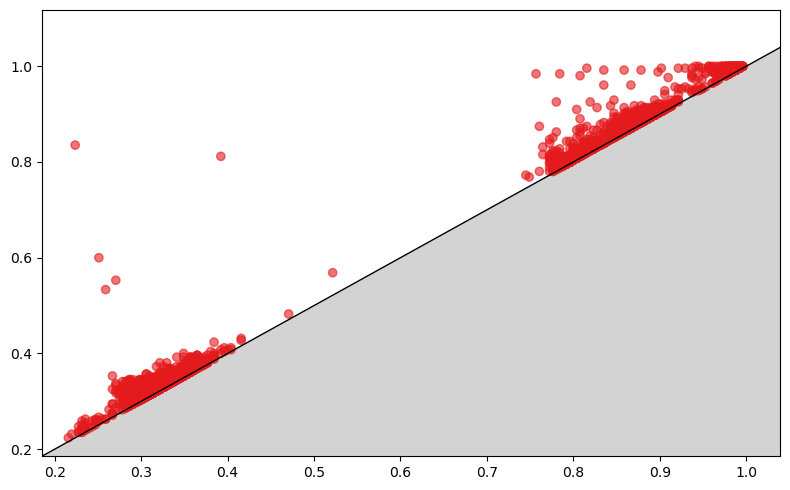

In [6]:
# non-infected
i = 823
cub_cpx = gd.CubicalComplex(vertices=noninfected[i])
cub_cpx.compute_persistence()
diag0_1 = cub_cpx.persistence_intervals_in_dimension(0)
diag0_1 = diag0_1[~np.isinf(diag0_1).any(axis=1)]
sil_noninfected = compute_silhouette([diag0_1], interval=interval, r=r, resolution=resolution)

# infected
j = 187
cub_cpx = gd.CubicalComplex(vertices=infected[j])
cub_cpx.compute_persistence()
diag0_2 = cub_cpx.persistence_intervals_in_dimension(0)
diag0_2 = diag0_2[~np.isinf(diag0_2).any(axis=1)]
sil_infected = compute_silhouette([diag0_2], interval=interval, r=r, resolution=resolution)


# plot ct images
fig, axs = plt.subplots(2, 1, figsize=(40, 10))
axs[0].imshow(noninfected[i][:, 6:-11], cmap="gray")
# axs[1].set_title("Noninfected", fontsize=15)
axs[0].set_ylabel("NonInfected", fontsize=30)
axs[0].tick_params(axis='both', which='both', labelsize=0)
axs[0].get_xaxis().set_ticks([])
axs[0].get_yaxis().set_ticks([])

axs[1].imshow(infected[j], cmap="gray")
# axs[0].set_title("Infected", fontsize=15)
axs[1].set_ylabel("Infected", fontsize=30)
axs[1].get_xaxis().set_ticks([])
axs[1].get_yaxis().set_ticks([])
plt.subplots_adjust(hspace=0.05)
plt.show();


# plot persistence diagrams
ax1 = gd.plot_persistence_diagram(diag0_1)
ax1.set_title("")
ax1.set_xlim(0.185, )
ax1.set_ylim(0.185, )
ax1.set_xlabel("")
ax1.set_ylabel("")
fig1 = plt.gcf()
fig1.set_size_inches(8, 5)
plt.tight_layout()
plt.show();

ax2 = gd.plot_persistence_diagram(diag0)
ax2.set_title("")
ax2.set_xlim(0.185, )
ax2.set_ylim(0.185, )
ax2.set_xlabel("")
ax2.set_ylabel("")
fig2 = plt.gcf()
fig2.set_size_inches(8, 5)
plt.tight_layout()
plt.show();

# Generate  potential outcome pair $(Y^0, Y^1)$

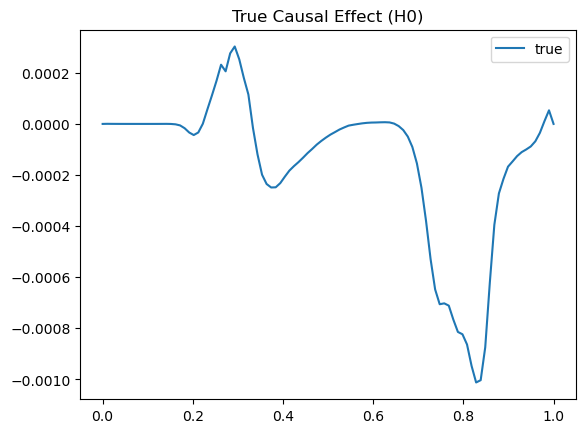

In [7]:
np.random.seed(42)

# generate 500 (Y^0, Y^1) pairs
n = 500
p = 0.75

idx_noninfected = np.random.choice(range(len(phi_noninfected)), int(n * p))
idx_infected = np.random.choice(range(len(phi_infected)), int(n * (2-p)))

potential_trt = np.vstack([phi_noninfected[idx_noninfected], phi_infected[idx_infected[n:]]])   # shape [n, n_hom, resolution]
potential_ctrl = phi_infected[idx_infected[:n]]                             # shape [n, n_hom, resolution]
potential_outcomes = np.stack([potential_ctrl, potential_trt], axis=1)      # shape [n, 2, n_hom, resolution]

true_effect = (np.mean(potential_trt, axis=0) - np.mean(potential_ctrl, axis=0)).squeeze()
plt.plot(tseq, true_effect, label="true")
plt.legend()
plt.title("True Causal Effect (H0)")
plt.show();

# Data generating process and treatment mechanism

Number of treated samples: 249, Number of non-treated samples: 251
Number of treated samples in subgroup1: 84, Number of non-treated samples in subgroup2: 166
Number of treated samples in subgroup2: 165, Number of non-treated samples in subgroup2: 85
Max propensity: 0.859682, Min propensity: 0.028105
Max propensity of subgroup1: 0.718531, Min propensity: 0.028105
Max propensity of subgroup2: 0.859682, Min propensity: 0.129689


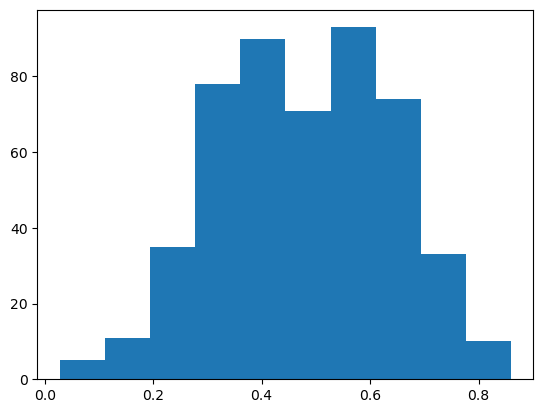

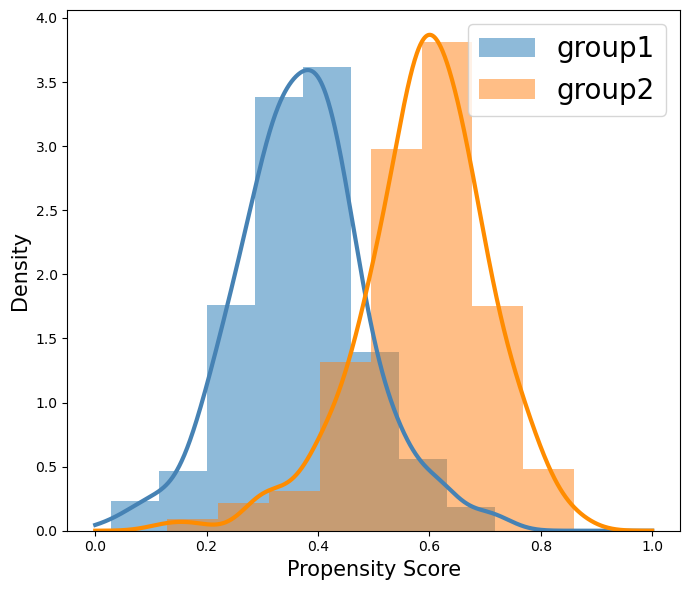

In [8]:
np.random.seed(42)
n_cov = 5   # number of covariates

# Data generating process
mu1 = np.array([1, 0.6, -0.7, 2.2, -1])     # mean vector of covariates subgroup 1
mu2 = np.array([0.4, -0.4, -0.6, 3.3, 3])   # mean vector of covariates subgroup 2
Sigma = np.eye(n_cov) * .5
covariate1, covariate2, covariate = gen_covariate(mu1, mu2, Sigma, n)   # generate covariates

# Treatment process
beta = np.array([-0.5, -0.1, 0.6, 0.1, 0.1])
prob, A = gen_trt_prob(covariate, beta)     # generate treatment

# construct observed data
observed_data = (potential_outcomes[range(n), A], A, covariate)    # (phi, A, X)

# histogram of entire dataset
print(f"Number of treated samples: {(A==1).sum()}, Number of non-treated samples: {(A==0).sum()}")
print(f"Number of treated samples in subgroup1: {(A[ :int(n/2)]==1).sum()}, Number of non-treated samples in subgroup2: {(A[ :int(n/2)]==0).sum()}")
print(f"Number of treated samples in subgroup2: {(A[int(n/2): ]==1).sum()}, Number of non-treated samples in subgroup2: {(A[int(n/2): ]==0).sum()}")
print(f"Max propensity: {prob.max():.6f}, Min propensity: {prob.min():.6f}")
print(f"Max propensity of subgroup1: {prob[ :int(n/2)].max():.6f}, Min propensity: {prob[ :int(n/2)].min():.6f}")
print(f"Max propensity of subgroup2: {prob[int(n/2): ].max():.6f}, Min propensity: {prob[int(n/2): ].min():.6f}")
plt.hist(prob)
plt.show();

# histogram of each subgroup
plt.figure(figsize=(7,6))
group1_prob, _ = gen_trt_prob(covariate1, beta)
group2_prob, _ = gen_trt_prob(covariate2, beta)
plt.hist(group1_prob, label="group1", alpha=0.5, density=True, bins=8)
plt.hist(group2_prob, label="group2", alpha=0.5, density=True, bins=8)
kde = gaussian_kde(group1_prob)
kde2 = gaussian_kde(group2_prob)
x_range = np.linspace(0, 1, 1000)
plt.plot(x_range, kde(x_range), c="steelblue", lw=3)
plt.plot(x_range, kde2(x_range), c="darkorange", lw=3)
# plt.title("Density of propensity score per subgroup", size=20)
plt.xlabel("Propensity Score", size=15)
plt.ylabel("Density", size=15)
plt.legend(prop={"size":20})
plt.tight_layout()
plt.show();

# Estimation

In [9]:
# sample split (one sample for fitting nuisance function and the other for estimation)
phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
sample1 = (phi1, A1, X1)
sample2 = (phi2, A2, X2)

## Repeat experiment 20 times

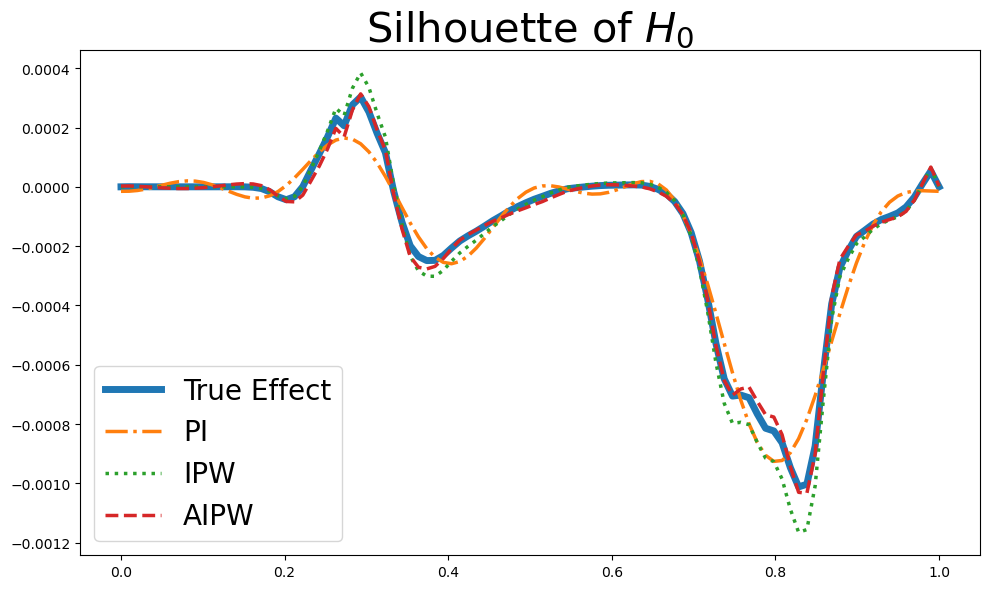

In [24]:
np.random.seed(42)

n_iter = 20
n_basis = 10
ipw_list, plugin_list, aipw_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n)     # generate covariates
    prob, A = gen_trt_prob(covariate, beta)                 # generate treatment

    # among those assigned to Y^1, 75% were data of non-infected and 25% were data of infected
    # change order of data such that the data of infected assigned to Y^1 have a higher probability of receiving treatment (makes estimation more challenging)
    size = int(n/2)
    subgroup2_idx = prob[-(n-size):].argsort() + size
    idx = np.concatenate([np.arange(int(size)), subgroup2_idx[-(n-size):]])
    covariate = covariate[idx]
    A = A[idx]
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin1, = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin2, = plugin_estimator(mu_hats2)
    # average
    plugin = (plugin1 + plugin2) / 2  # homology dim 0
    plugin_list.append(plugin)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = RandomForestClassifier().fit(X1, A1).predict_proba(X2)[:,1]
    ipw1, = ipw_estimator(pi_hat1, sample2)
    # fit on sample 2, estimate on sample 1
    pi_hat2 = RandomForestClassifier().fit(X2, A2).predict_proba(X1)[:,1]
    ipw2, = ipw_estimator(pi_hat2, sample1)
    # average
    ipw = (ipw1 + ipw2) / 2     # homology dim 0
    ipw_list.append(ipw)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw1, = aipw_estimator(pi_hat1, mu_hats1, sample2) # fit on sample 1, estimate on sample 2
    # fit on sample 2, estimate on sample 1
    aipw2, = aipw_estimator(pi_hat2, mu_hats2, sample1) # fit on sample 2, estimate on sample 1
    # average
    aipw = (aipw1 + aipw2) / 2  # homology dim 0
    aipw_list.append(aipw)


# plot
lw = 2.5

ipw_avg = np.array(ipw_list).mean(axis=0)
ipw_std = np.array(ipw_list).std(axis=0)
pi_avg = np.array(plugin_list).mean(axis=0)
pi_std = np.array(plugin_list).std(axis=0)
aipw_avg = np.array(aipw_list).mean(axis=0)
aipw_std = np.array(aipw_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect, label="True Effect", lw=2*lw)
plt.plot(tseq, pi_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.0013, 0.0013)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

## $L_1$ distance and Std.

In [25]:
# L1 distance between true effect and average estimated effect
l1_pi = numerical_integration(np.abs(true_effect - pi_avg), tseq)
l1_ipw = numerical_integration(np.abs(true_effect - ipw_avg), tseq)
l1_aipw = numerical_integration(np.abs(true_effect - aipw_avg), tseq)

print(f"L1 dist: PI:{l1_pi} IPW:{l1_ipw} AIPW:{l1_aipw}")

# covariance
cov_pi = np.cov(np.array(plugin_list), rowvar=False)
cov_ipw = np.cov(np.array(ipw_list), rowvar=False)
cov_aipw = np.cov(np.array(aipw_list), rowvar=False)

print(f"Std.: PI:{np.sqrt(cov_pi.mean())} IPW:{np.sqrt(cov_ipw.mean())} AIPW:{np.sqrt(cov_aipw.mean())}")

L1 dist: PI:4.543854636350588e-05 IPW:2.9355877086397227e-05 AIPW:1.2456514860634026e-05
Std.: PI:2.711742274596505e-05 IPW:9.034797930791782e-05 AIPW:3.099049316589444e-05


## Plot error band

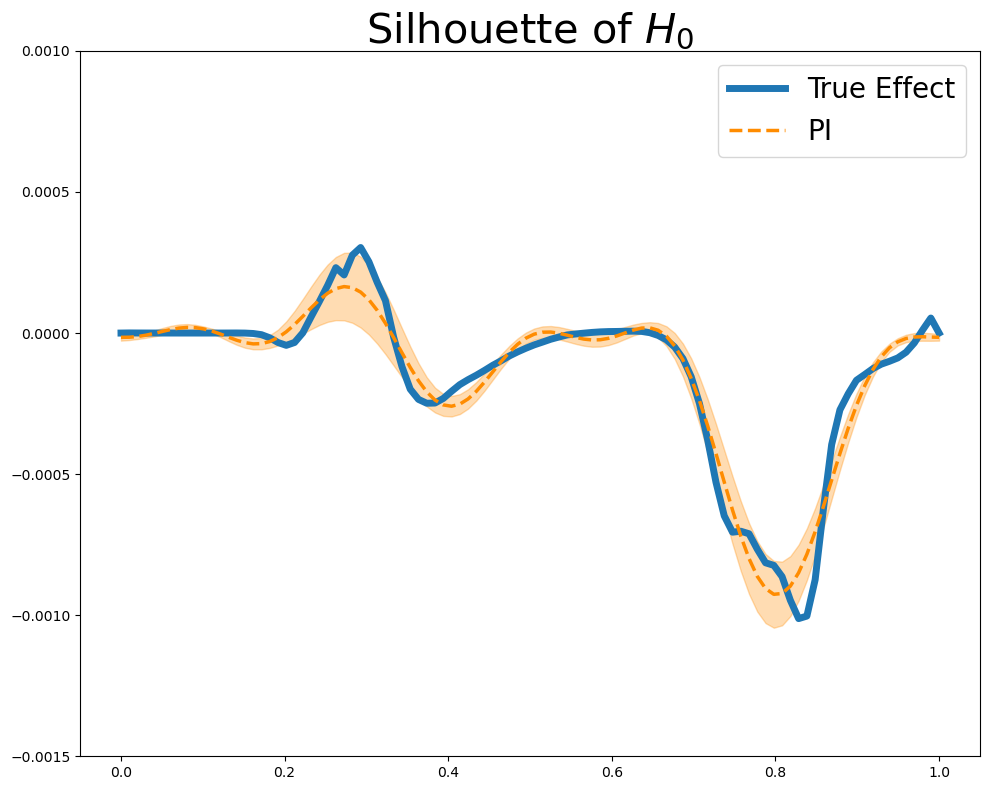

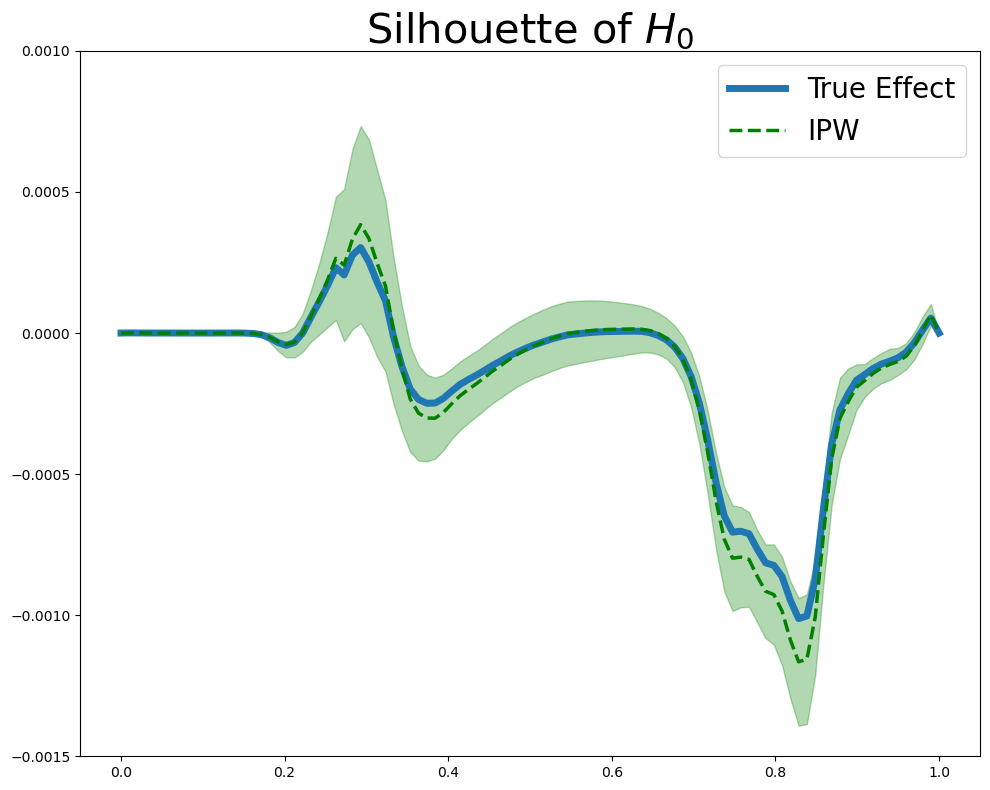

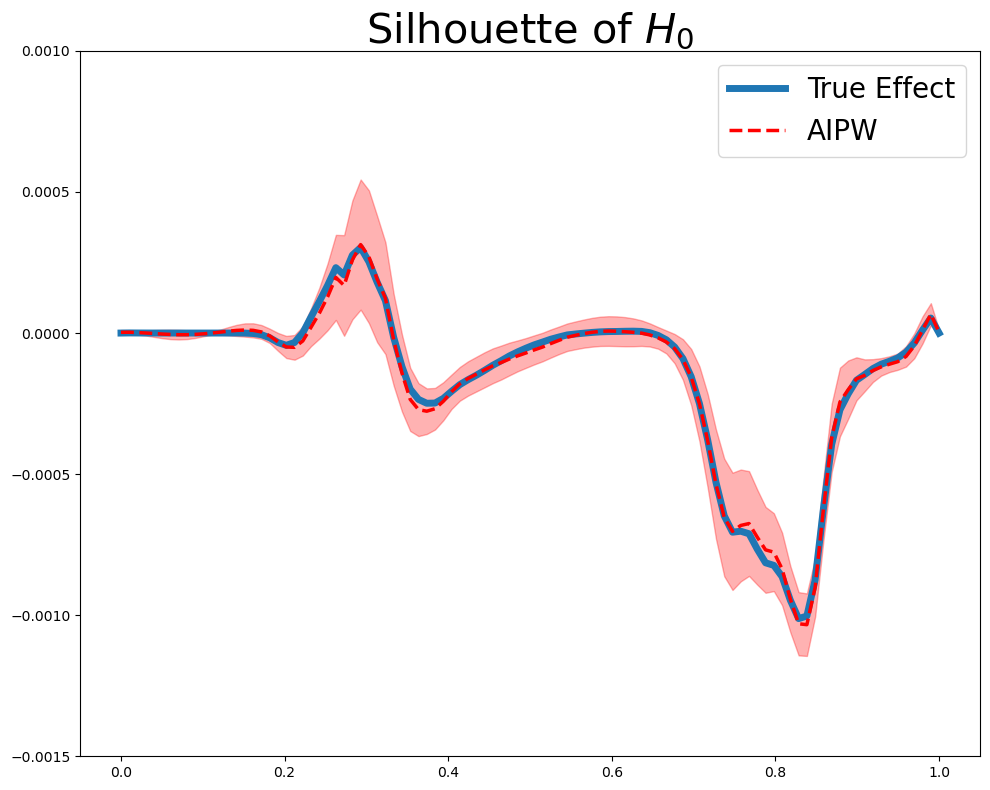

In [26]:
# plugin
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect, label="True Effect", lw=2*lw)
plt.plot(tseq, pi_avg, label="PI", ls="--", lw=lw, color="darkorange")
plt.fill_between(tseq, pi_avg - pi_std, pi_avg + pi_std, alpha=0.3, color="darkorange")
plt.ylim(-0.0015, 0.001)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# ipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect, label="True Effect", lw=2*lw)
plt.plot(tseq, ipw_avg, label="IPW", ls="--", lw=lw, color="green")
plt.fill_between(tseq, ipw_avg - ipw_std, ipw_avg + ipw_std, alpha=0.3, color="green")
plt.ylim(-0.0015, 0.001)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# aipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect, label="True Effect", lw=2*lw)
plt.plot(tseq, aipw_avg, label="AIPW", ls="--", lw=lw, color="red")
plt.fill_between(tseq, aipw_avg - aipw_std, aipw_avg + aipw_std, alpha=0.3, color="red")
plt.ylim(-0.0015, 0.001)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# Estimation under Model Misspecification

## Misspecification of $\pi$

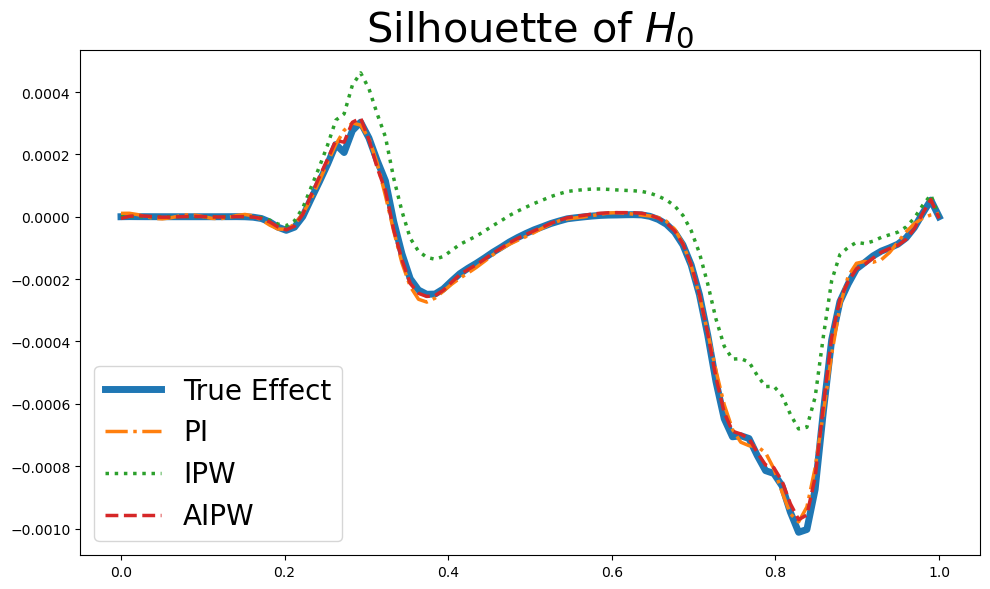

In [27]:
np.random.seed(42)

n_iter = 20
n_basis = 30
ipw_list, plugin_list, aipw_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n)     # generate covariates
    prob, A = gen_trt_prob(covariate, beta)                 # generate treatment

    # among those assigned to Y^1, 75% were data of non-infected and 25% were data of infected
    # change order of data such that the data of infected assigned to Y^1 have a higher probability of receiving treatment (makes estimation more challenging)
    size = int(n/2)
    subgroup2_idx = prob[-(n-size):].argsort() + size
    idx = np.concatenate([np.arange(int(size)), subgroup2_idx[-(n-size):]])
    covariate = covariate[idx]
    A = A[idx]
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin1, = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin2, = plugin_estimator(mu_hats2)
    # average
    plugin = (plugin1 + plugin2) / 2  # homology dim 0
    plugin_list.append(plugin)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = LogisticRegression(fit_intercept=False, penalty=None).fit(X1[:, [0, 2]], A1).predict_proba(X2[:, [0, 2]])[:,1]
    ipw1, = ipw_estimator(pi_hat1, sample2)
    # fit on sample 2, estimate on sample 1
    pi_hat2 = LogisticRegression(fit_intercept=False, penalty=None).fit(X2[:, [0, 2]], A2).predict_proba(X1[:, [0, 2]])[:,1]
    ipw2, = ipw_estimator(pi_hat2, sample1)
    # average
    ipw = (ipw1 + ipw2) / 2  # homology dim 0
    ipw_list.append(ipw)

    # aipw
    aipw1, = aipw_estimator(pi_hat1, mu_hats1, sample2) # fit on sample 1, estimate on sample 2
    aipw2, = aipw_estimator(pi_hat2, mu_hats2, sample1) # fit on sample 2, estimate on sample 1
    aipw = (aipw1 + aipw2) / 2     # homology dim 0
    aipw_list.append(aipw)


# plot
ipw_avg = np.array(ipw_list).mean(axis=0)
ipw_std = np.array(ipw_list).std(axis=0)
pi_avg = np.array(plugin_list).mean(axis=0)
pi_std = np.array(plugin_list).std(axis=0)
aipw_avg = np.array(aipw_list).mean(axis=0)
aipw_std = np.array(aipw_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect, label="True Effect", lw=2*lw)
plt.plot(tseq, pi_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.0013, 0.0013)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

### $L_1$ distance and Std.

In [28]:
# L1 distance between true effect and average estimated effect
l1_pi = numerical_integration(np.abs(true_effect - pi_avg), tseq)
l1_ipw = numerical_integration(np.abs(true_effect - ipw_avg), tseq)
l1_aipw = numerical_integration(np.abs(true_effect - aipw_avg), tseq)

print(f"L1 dist: PI:{l1_pi} IPW:{l1_ipw} AIPW:{l1_aipw}")

# covariance
cov_pi = np.cov(np.array(plugin_list), rowvar=False)
cov_ipw = np.cov(np.array(ipw_list), rowvar=False)
cov_aipw = np.cov(np.array(aipw_list), rowvar=False)

print(f"Std.: PI:{np.sqrt(cov_pi.mean())} IPW:{np.sqrt(cov_ipw.mean())} AIPW:{np.sqrt(cov_aipw.mean())}")

L1 dist: PI:1.3900654933172893e-05 IPW:9.673508458721354e-05 AIPW:7.863796940675999e-06
Std.: PI:3.1323192371368446e-05 IPW:4.421100969347568e-05 AIPW:2.7613006001832167e-05


## Misspecification of $\mu$

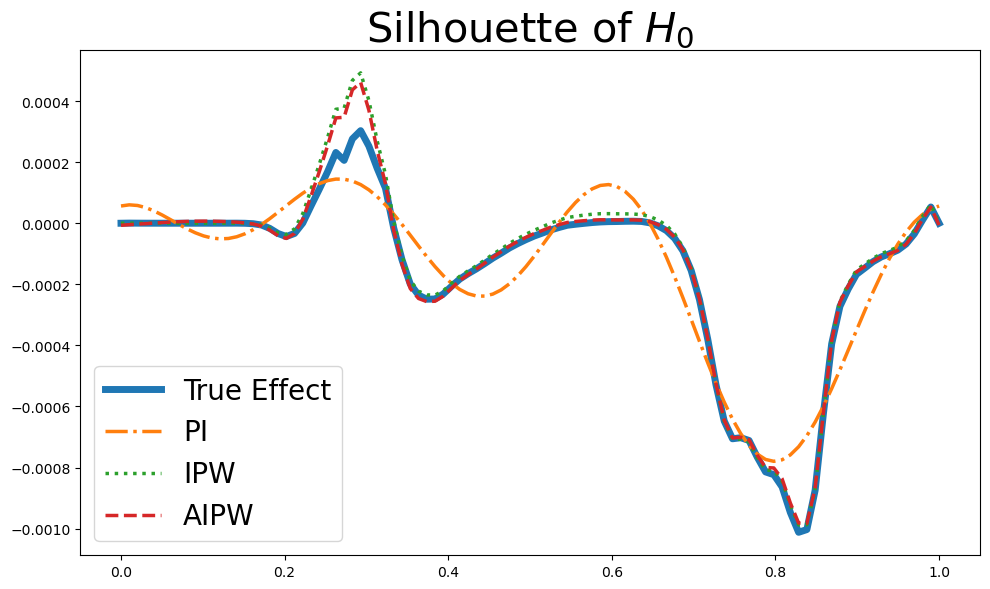

In [29]:
np.random.seed(42)

n_iter = 20
n_basis = 7
ipw_list, plugin_list, aipw_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n)     # generate covariates
    prob, A = gen_trt_prob(covariate, beta)                 # generate treatment

    # among those assigned to Y^1, 75% were data of non-infected and 25% were data of infected
    # change order of data such that the data of infected assigned to Y^1 have a higher probability of receiving treatment (makes estimation more challenging)
    size = int(n/2)
    subgroup2_idx = prob[-(n-size):].argsort() + size
    idx = np.concatenate([np.arange(int(size)), subgroup2_idx[-(n-size):]])
    covariate = covariate[idx]
    A = A[idx]
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin1, = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin2, = plugin_estimator(mu_hats2)
    # average
    plugin = (plugin1 + plugin2) / 2  # homology dim 0
    plugin_list.append(plugin)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = LogisticRegression(fit_intercept=False, penalty=None).fit(np.hstack([X1, X1[:,[1]]*X1[:,[2]], X1[:,[0]]*X1[:,[2]]]), A1).predict_proba(np.hstack([X2, X2[:,[1]]*X2[:,[2]], X2[:,[0]]*X2[:,[2]]]))[:,1]
    ipw1, = ipw_estimator(pi_hat1, sample2)
    # fit on sample 2, estimate on sample 1
    pi_hat2 = LogisticRegression(fit_intercept=False, penalty=None).fit(np.hstack([X2, X2[:,[1]]*X2[:,[2]], X2[:,[0]]*X2[:,[2]]]), A2).predict_proba(np.hstack([X1, X1[:,[1]]*X1[:,[2]], X1[:,[0]]*X1[:,[2]]]))[:,1]
    ipw2, = ipw_estimator(pi_hat2, sample1)
    # average
    ipw = (ipw1 + ipw2) / 2  # homology dim 0
    ipw_list.append(ipw)

    # aipw
    aipw1, = aipw_estimator(pi_hat1, mu_hats1, sample2) # fit on sample 1, estimate on sample 2
    aipw2, = aipw_estimator(pi_hat2, mu_hats2, sample1) # fit on sample 2, estimate on sample 1
    aipw = (aipw1 + aipw2) / 2     # homology dim 0
    aipw_list.append(aipw)


# plot
ipw_avg = np.array(ipw_list).mean(axis=0)
ipw_std = np.array(ipw_list).std(axis=0)
pi_avg = np.array(plugin_list).mean(axis=0)
pi_std = np.array(plugin_list).std(axis=0)
aipw_avg = np.array(aipw_list).mean(axis=0)
aipw_std = np.array(aipw_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect, label="True Effect", lw=2*lw)
plt.plot(tseq, pi_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.0013, 0.0013)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

### $L_1$ distance and Std.

In [30]:
# L1 distance between true effect and average estimated effect
l1_pi = numerical_integration(np.abs(true_effect - pi_avg), tseq)
l1_ipw = numerical_integration(np.abs(true_effect - ipw_avg), tseq)
l1_aipw = numerical_integration(np.abs(true_effect - aipw_avg), tseq)

print(f"L1 dist: PI:{l1_pi} IPW:{l1_ipw} AIPW:{l1_aipw}")

# covariance
cov_pi = np.cov(np.array(plugin_list), rowvar=False)
cov_ipw = np.cov(np.array(ipw_list), rowvar=False)
cov_aipw = np.cov(np.array(aipw_list), rowvar=False)

print(f"Std.: PI:{np.sqrt(cov_pi.mean())} IPW:{np.sqrt(cov_ipw.mean())} AIPW:{np.sqrt(cov_aipw.mean())}")

L1 dist: PI:7.984841182350593e-05 IPW:2.24313373196474e-05 AIPW:1.5294842725476807e-05
Std.: PI:3.132319237136847e-05 IPW:4.328414069345655e-05 AIPW:3.394939949427381e-05
